# Separate-session image-to-video dRSA

Loads an image-session raster and a video-session raster separately, aligns their shared stimulus identities, and reproduces the neural and model analyses from `image_to_video_dRSA.ipynb`.

The image-session neural responses come from JPEG presentations. The static model comparison uses the configured frame of each matching video feature sequence; for the current stimuli, the final video frame corresponds to the presented JPEG.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml


def find_project_root(start_path: Path) -> Path:
    '''Return the nearest parent directory containing config.yaml.'''
    for path in (start_path, *start_path.parents):
        if (path / "config.yaml").exists():
            return path
        # end if config.yaml exists
    # end for path
    raise FileNotFoundError("Could not find config.yaml from the notebook directory.")
# EOF


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
ENV = os.getenv("MY_ENV", "tiziano_mac_mini")

with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]["paths"]
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from image_processing.video_feature_extraction import (
    list_video_feature_files,
    load_aligned_video_features,
    match_feature_stimulus_names,
    stimulus_key,
)
from project_specific_utils import load_natraster, min_max_normalization
from useful_stuff.general_utils import (
    TimeSeries,
    create_RDM,
    get_lagplot_subset,
)
from useful_stuff.general_utils.RSA import dRSA

In [2]:
@dataclass
class Cfg:
    image_exp_name: str = "baby1_260718"
    video_exp_name: str = "baby1_260717"

    # MATLAB channels 84--186 inclusive; Python stop indices are exclusive.
    good_channels: tuple[int, int] = (84, 186)
    # Optional zero-based slice relative to good_channels; None keeps all sites.
    analysis_channels: tuple[int, int] | None = (17, 25)
    image_crop_ms: int | None = 1000
    video_crop_ms: int | None = None
    new_fs: float | None = 60
    normalization: str | None = None  # Supported: None or "min_max".

    signal_RDM_metric: str = "cosine_cnt"
    model_RDM_metric: str = "cosine_cnt"
    image_RSA_metric: str = "spearman"
    cross_session_RSA_metric: str = "correlation"
    video_RSA_metric: str = "correlation"

    cross_session_lag_analysis_end_ms: float = 1000
    video_lag_analysis_end_ms: float = 1000
    max_lag_ms: float = 700

    model_name: str = "ijepa_vith14_1k"
    model_dataset_name: str = "static_dynamic"
    model_pooling: str | None = "mean"
    model_features_dir: Path | None = None
    static_model_frame_index: int = -1
    example_layer_index: int = 12
# EOC


cfg = Cfg()
data_dir = Path(paths["data_path"]) / "data"
image_natraster_path = data_dir / f"{cfg.image_exp_name}_natraster_img.mat"
video_natraster_path = data_dir / f"{cfg.video_exp_name}_natraster_vid.mat"
cfg

Cfg(image_exp_name='baby1_260718', video_exp_name='baby1_260717', good_channels=(84, 186), analysis_channels=(17, 25), image_crop_ms=1000, video_crop_ms=None, new_fs=60, normalization=None, signal_RDM_metric='cosine_cnt', model_RDM_metric='cosine_cnt', image_RSA_metric='spearman', cross_session_RSA_metric='correlation', video_RSA_metric='correlation', cross_session_lag_analysis_end_ms=1000, video_lag_analysis_end_ms=1000, max_lag_ms=700, model_name='ijepa_vith14_1k', model_dataset_name='static_dynamic', model_pooling='mean', model_features_dir=None, static_model_frame_index=-1, example_layer_index=12)

## Load and align the two sessions

Every condition in each modality-specific session is retained when it has a partner in the other session. Alignment uses stimulus identity rather than relying on MATLAB ordering or identical filenames.

In [3]:
image_rasters_all, image_names_all = load_natraster(image_natraster_path)
video_rasters_all, video_names_all = load_natraster(video_natraster_path)

# Build one-to-one lookup tables without assuming that the sessions share order.
image_keys = [stimulus_key(name) for name in image_names_all]
video_keys = [stimulus_key(name) for name in video_names_all]
if len(image_keys) != len(set(image_keys)):
    raise ValueError("The image session contains duplicate stimulus identities.")
# end if duplicate image identities
if len(video_keys) != len(set(video_keys)):
    raise ValueError("The video session contains duplicate stimulus identities.")
# end if duplicate video identities

image_index_by_key = {key: index for index, key in enumerate(image_keys)}
video_index_by_key = {key: index for index, key in enumerate(video_keys)}
# Preserve the image session's MATLAB ordering for every downstream array.
shared_stimuli = [key for key in image_keys if key in video_index_by_key]
if len(shared_stimuli) < 2:
    raise ValueError("Need at least two shared image/video stimulus identities.")
# end if len(shared_stimuli)

image_order = [image_index_by_key[key] for key in shared_stimuli]
video_order = [video_index_by_key[key] for key in shared_stimuli]
image_names = [image_names_all[index] for index in image_order]
video_names = [video_names_all[index] for index in video_order]
image_rasters = image_rasters_all[:, :, image_order]
video_rasters = video_rasters_all[:, :, video_order]

print(f"Image raster: {image_natraster_path.resolve()}")
print(f"Video raster: {video_natraster_path.resolve()}")
print(f"Shared stimuli: {len(shared_stimuli)}")
print(f"Image-only identities omitted: {len(set(image_keys) - set(video_keys))}")
print(f"Video-only identities omitted: {len(set(video_keys) - set(image_keys))}")
print("First aligned pair:", image_names[0], "<->", video_names[0])

Image raster: /Users/tizianocausin/sd_local/data/baby1_260718_natraster.mat
Video raster: /Users/tizianocausin/sd_local/data/baby1_260717_natraster.mat
Shared stimuli: 100
Image-only identities omitted: 0
Video-only identities omitted: 0
First aligned pair: img_0_0_41171.jpg <-> vid_0_0_41171.mp4


In [4]:
# Apply the same physical channel selection to both recording sessions.
first_channel, last_channel = cfg.good_channels
if first_channel < 1 or last_channel > min(image_rasters.shape[0], video_rasters.shape[0]):
    raise IndexError("good_channels falls outside one of the raster channel axes.")
# end if good_channels
channel_slice = slice(first_channel - 1, last_channel)
image_time_slice = (
    slice(None) if cfg.image_crop_ms is None else slice(0, cfg.image_crop_ms)
)
video_time_slice = (
    slice(None) if cfg.video_crop_ms is None else slice(0, cfg.video_crop_ms)
)
image_rasters = image_rasters[channel_slice, image_time_slice, :]
video_rasters = video_rasters[channel_slice, video_time_slice, :]

if cfg.analysis_channels is not None:
    first_analysis_channel, last_analysis_channel = cfg.analysis_channels
    analysis_slice = slice(first_analysis_channel, last_analysis_channel)
    image_rasters = image_rasters[analysis_slice, :, :]
    video_rasters = video_rasters[analysis_slice, :, :]
# end if cfg.analysis_channels

if image_rasters.shape[0] != video_rasters.shape[0]:
    raise ValueError("Image and video analyses must use the same number of channels.")
# end if channel counts differ

image_neural_ts = TimeSeries(image_rasters, fs=1000)
video_neural_ts = TimeSeries(video_rasters, fs=1000)
if cfg.new_fs is not None:
    image_neural_ts.resample(cfg.new_fs)
    video_neural_ts.resample(cfg.new_fs)
# end if cfg.new_fs

if cfg.normalization == "min_max":
    # Shared bounds keep matched physical channels on the same scale.
    normalization_reference = np.concatenate([
        image_neural_ts.get_array().reshape(image_neural_ts.shape()[0], -1),
        video_neural_ts.get_array().reshape(video_neural_ts.shape()[0], -1),
    ], axis=1)
    image_neural_ts.set_array(min_max_normalization(
        image_neural_ts.get_array(), reference_data=normalization_reference,
    ))
    video_neural_ts.set_array(min_max_normalization(
        video_neural_ts.get_array(), reference_data=normalization_reference,
    ))
elif cfg.normalization is not None:
    raise ValueError("cfg.normalization must be None or 'min_max'")
# end if cfg.normalization

print(f"Image neural data: {image_neural_ts.shape()} (channels, time, stimuli)")
print(f"Video neural data: {video_neural_ts.shape()} (channels, time, stimuli)")
print(f"Shared sampling frequency: {image_neural_ts.get_fs():g} Hz")

Image neural data: (8, 60, 100) (channels, time, stimuli)
Video neural data: (8, 60, 100) (channels, time, stimuli)
Shared sampling frequency: 60 Hz


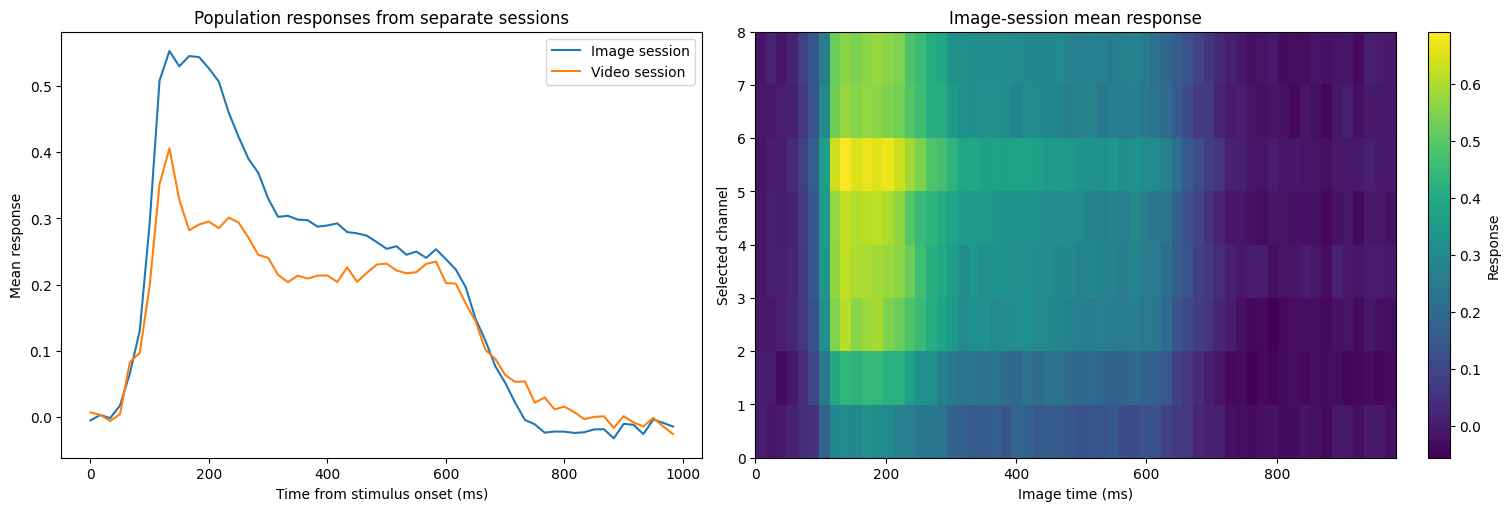

In [5]:
image_time_ms = np.arange(image_neural_ts.shape()[1]) * 1000 / image_neural_ts.get_fs()
video_time_ms = np.arange(video_neural_ts.shape()[1]) * 1000 / video_neural_ts.get_fs()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
axes[0].plot(
    image_time_ms, image_neural_ts.get_array().mean(axis=(0, 2)),
    color="tab:blue", label="Image session",
)
axes[0].plot(
    video_time_ms, video_neural_ts.get_array().mean(axis=(0, 2)),
    color="tab:orange", label="Video session",
)
axes[0].set(xlabel="Time from stimulus onset (ms)", ylabel="Mean response",
            title="Population responses from separate sessions")
axes[0].legend()
response_image = axes[1].imshow(
    image_neural_ts.get_array().mean(axis=2), aspect="auto", origin="lower",
    extent=[image_time_ms[0], image_time_ms[-1], 0, image_neural_ts.shape()[0]],
)
axes[1].set(xlabel="Image time (ms)", ylabel="Selected channel",
            title="Image-session mean response")
fig.colorbar(response_image, ax=axes[1], label="Response")

## Cross-session neural comparisons

First, channel patterns are correlated across image and video time for each matched stimulus and then averaged. Second, time-resolved RDMs compare representational geometry across all matched stimuli. Rows always represent video time and columns represent image time.

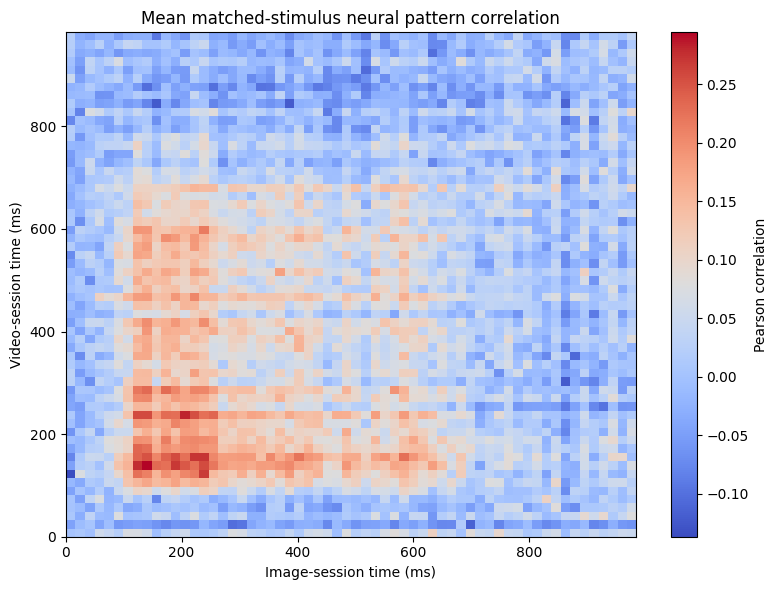

In [6]:
stimulus_pattern_correlations = []
for stimulus_index in range(len(shared_stimuli)):
    video_stimulus_ts = TimeSeries(
        video_neural_ts.get_array()[:, :, stimulus_index],
        fs=video_neural_ts.get_fs(),
    )
    image_stimulus_ts = TimeSeries(
        image_neural_ts.get_array()[:, :, stimulus_index],
        fs=image_neural_ts.get_fs(),
    )
    stimulus_pattern_correlations.append(
        video_stimulus_ts.lagged_corr(image_stimulus_ts)
    )
# end for stimulus_index
mean_stimulus_pattern_correlation = np.nanmean(
    np.stack(stimulus_pattern_correlations, axis=0), axis=0,
)

fig, ax = plt.subplots(figsize=(8, 6))
correlation_image = ax.imshow(
    mean_stimulus_pattern_correlation, aspect="auto", origin="lower",
    cmap="coolwarm",
    extent=[image_time_ms[0], image_time_ms[-1],
            video_time_ms[0], video_time_ms[-1]],
)
ax.set(xlabel="Image-session time (ms)", ylabel="Video-session time (ms)",
       title="Mean matched-stimulus neural pattern correlation")
fig.colorbar(correlation_image, ax=ax, label="Pearson correlation")
fig.tight_layout()

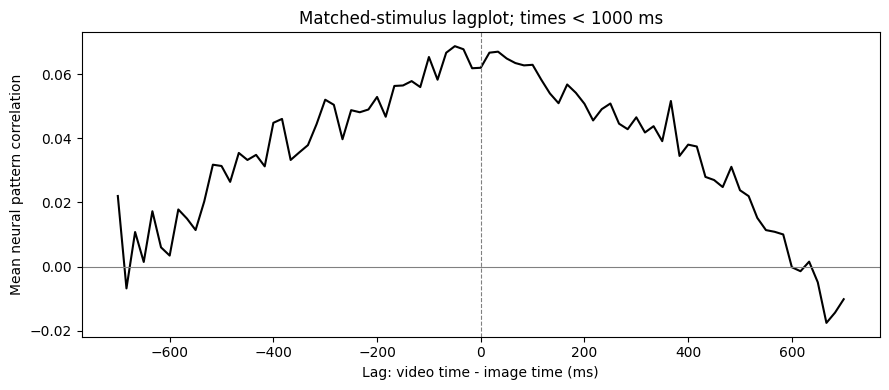

In [7]:
lag_fs = image_neural_ts.get_fs()
cross_session_end_ms = min(
    cfg.cross_session_lag_analysis_end_ms,
    image_neural_ts.get_duration_ms(),
    video_neural_ts.get_duration_ms(),
)
image_lag_indices = np.flatnonzero(image_time_ms < cross_session_end_ms)
video_lag_indices = np.flatnonzero(video_time_ms < cross_session_end_ms)
requested_max_lag_samples = int(round(cfg.max_lag_ms * lag_fs / 1000))
max_lag_samples = min(
    requested_max_lag_samples,
    len(image_lag_indices) - 1,
    len(video_lag_indices) - 1,
)
if max_lag_samples < 1:
    raise ValueError("The selected cross-session lag window is too short.")
# end if max_lag_samples
lag_ms = np.arange(-max_lag_samples, max_lag_samples + 1) * 1000 / lag_fs
neural_pattern_lagplot = get_lagplot_subset(
    mean_stimulus_pattern_correlation,
    neural_idx=video_lag_indices,
    model_idx=image_lag_indices,
    max_lag=max_lag_samples,
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lag_ms, neural_pattern_lagplot, color="black")
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set(xlabel="Lag: video time - image time (ms)",
       ylabel="Mean neural pattern correlation",
       title=f"Matched-stimulus lagplot; times < {cross_session_end_ms:g} ms")
fig.tight_layout()

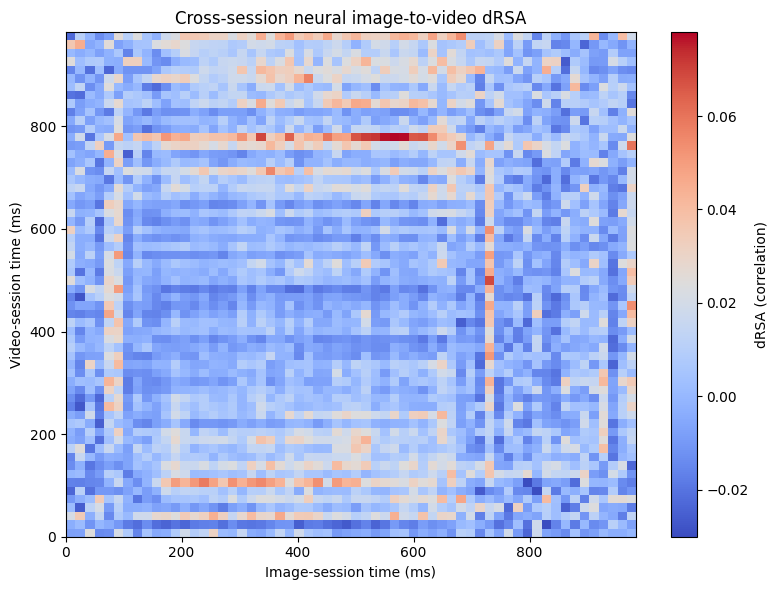

In [8]:
cross_session_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.signal_RDM_metric,
    RSA_metric=cfg.cross_session_RSA_metric,
)
# The signal axis becomes rows (video time); the model axis becomes columns (image time).
cross_session_drsa.compute_both_RDM_timeseries(
    video_neural_ts, image_neural_ts,
)
neural_cross_session_drsa = cross_session_drsa.compute_dRSA()

fig, ax = plt.subplots(figsize=(8, 6))
drsa_image = ax.imshow(
    neural_cross_session_drsa, aspect="auto", origin="lower",
    cmap="coolwarm",
    extent=[image_time_ms[0], image_time_ms[-1],
            video_time_ms[0], video_time_ms[-1]],
)
ax.set(xlabel="Image-session time (ms)", ylabel="Video-session time (ms)",
       title="Cross-session neural image-to-video dRSA")
fig.colorbar(drsa_image, ax=ax, label=f"dRSA ({cfg.cross_session_RSA_metric})")
fig.tight_layout()

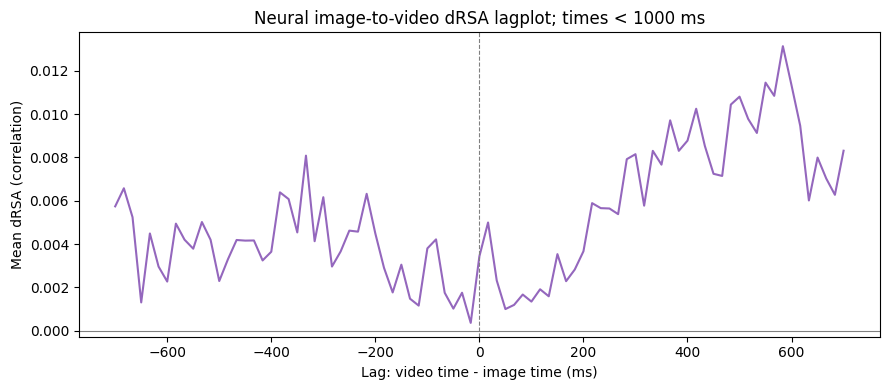

In [9]:
neural_drsa_lagplot = get_lagplot_subset(
    neural_cross_session_drsa,
    neural_idx=video_lag_indices,
    model_idx=image_lag_indices,
    max_lag=max_lag_samples,
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lag_ms, neural_drsa_lagplot, color="tab:purple")
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set(xlabel="Lag: video time - image time (ms)",
       ylabel=f"Mean dRSA ({cfg.cross_session_RSA_metric})",
       title=f"Neural image-to-video dRSA lagplot; times < {cross_session_end_ms:g} ms")
fig.tight_layout()

## Align model features

Layer-specific HDF5 datasets are reordered to the shared neural stimulus sequence. Prefix and extension differences do not affect matching. The same matched video sequence supplies the configured static frame for image dRSA and all frames for video dRSA.

In [10]:
model_features_dir = (
    cfg.model_features_dir or Path(paths["data_path"]) / "models"
)
feature_paths = list_video_feature_files(
    model_features_dir,
    cfg.model_name,
    cfg.model_dataset_name,
    cfg.model_pooling,
)
image_feature_names = match_feature_stimulus_names(feature_paths[0], image_names)
video_feature_names = match_feature_stimulus_names(feature_paths[0], video_names)
if image_feature_names != video_feature_names:
    raise ValueError("Image and video sessions mapped to different model datasets.")
# end if model mappings differ

print(f"Model layers: {len(feature_paths)}")
print("First neural/model mappings:")
for image_name, video_name, feature_name in zip(
    image_names[:5], video_names[:5], video_feature_names[:5],
):
    print(f"  {image_name} <-> {video_name} -> {feature_name}")
# end for image_name, video_name, feature_name

Model layers: 32
First neural/model mappings:
  img_0_0_41171.jpg <-> vid_0_0_41171.mp4 -> vid_0_0_41171.mp4
  img_1500_animal_names1.jpg <-> vid_1500_animal_names1.mp4 -> vid_1500_animal_names1.mp4
  img_4115_11.01.jpg <-> vid_4115_11.01.mp4 -> vid_4115_11.01.mp4
  img_43.81_41411.jpg <-> vid_43.81_41411.mp4 -> vid_43.81_41411.mp4
  img_4_5_41241.jpg <-> vid_4_5_41241.mp4 -> vid_4_5_41241.mp4


## Static model dRSA against the image session

The neural image RDM changes over post-onset time. Each model layer contributes one static RDM from the configured matching video frame.

In [11]:
image_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.image_RSA_metric,
)
image_drsa.compute_RDM_timeseries(image_neural_ts, "signal")

image_layer_drsa = []
layer_names = []
for feature_path in feature_paths:
    static_features, layer_name, _ = load_aligned_video_features(
        feature_path,
        image_feature_names,
        frame_index=cfg.static_model_frame_index,
    )
    model_RDM = create_RDM(static_features, metric=cfg.model_RDM_metric)
    image_drsa.set_RDM(model_RDM, "model")
    image_layer_drsa.append(
        image_drsa.compute_static_dRSA().get_array().copy()
    )
    layer_names.append(layer_name)
# end for feature_path
image_layer_drsa = np.stack(image_layer_drsa, axis=0)
print(f"Image static dRSA: {image_layer_drsa.shape} (layers, neural time)")

Image static dRSA: (32, 60) (layers, neural time)


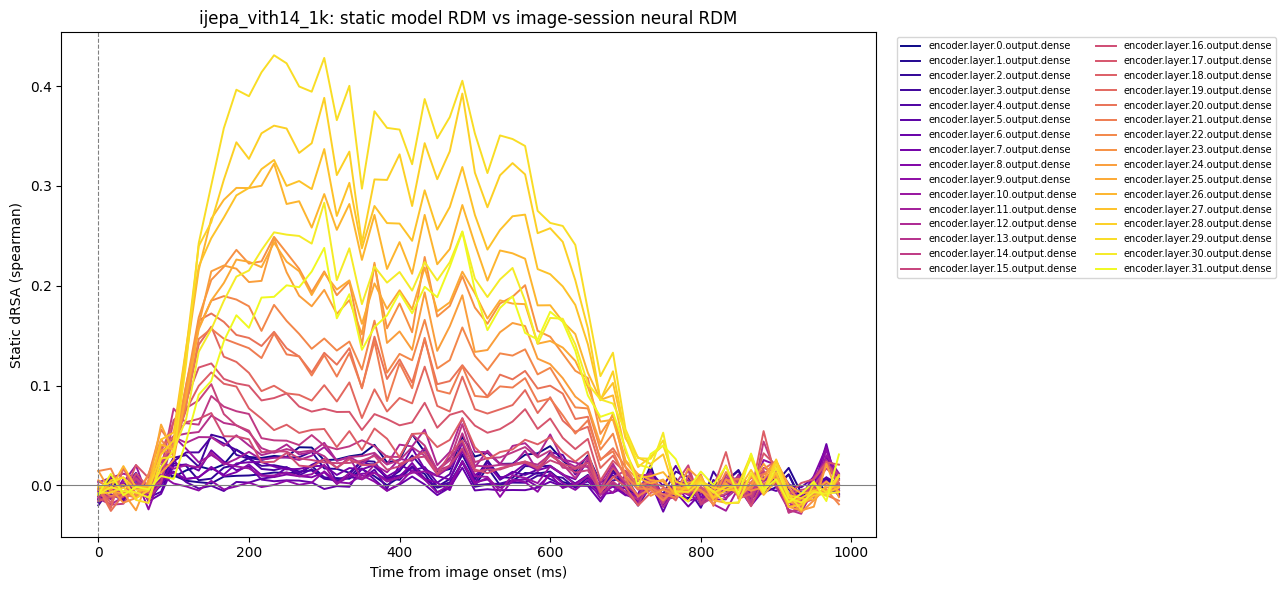

In [12]:
layer_colors = plt.cm.plasma(np.linspace(0, 1, len(layer_names)))
fig, ax = plt.subplots(figsize=(13, 6))
for layer_index, (layer_name, layer_drsa) in enumerate(
    zip(layer_names, image_layer_drsa)
):
    ax.plot(image_time_ms, layer_drsa, color=layer_colors[layer_index],
            linewidth=1.4, label=layer_name)
# end for layer_index
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set(xlabel="Time from image onset (ms)",
       ylabel=f"Static dRSA ({cfg.image_RSA_metric})",
       title=f"{cfg.model_name}: static model RDM vs image-session neural RDM")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=2)
fig.tight_layout()

## Sequential model dRSA against the video session

For each layer, the neural video RDM timecourse is compared with the complete model video RDM timecourse. Model features are resampled to the neural analysis rate before computing dRSA.

In [13]:
video_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.video_RSA_metric,
)
video_drsa.compute_RDM_timeseries(video_neural_ts, "signal")

video_layer_drsa = {}
source_model_fs = None
for feature_path in feature_paths:
    model_features, layer_name, layer_model_fs = load_aligned_video_features(
        feature_path, video_feature_names, frame_index=None,
    )
    model_ts = TimeSeries(model_features, fs=layer_model_fs)
    model_ts.resample(video_neural_ts.get_fs())
    video_drsa.compute_RDM_timeseries(model_ts, "model")
    video_layer_drsa[layer_name] = video_drsa.compute_dRSA().copy()

    if source_model_fs is None:
        source_model_fs = layer_model_fs
    elif source_model_fs != layer_model_fs:
        raise ValueError("Model layers have inconsistent source frame rates.")
    # end if source_model_fs
# end for feature_path

if not 0 <= cfg.example_layer_index < len(layer_names):
    raise IndexError(
        f"example_layer_index must be between 0 and {len(layer_names) - 1}"
    )
# end if example_layer_index
model_fs = video_neural_ts.get_fs()
example_layer = layer_names[cfg.example_layer_index]
example_video_drsa = video_layer_drsa[example_layer]
model_time_ms = np.arange(example_video_drsa.shape[1]) * 1000 / model_fs
print(
    f"Video dRSA: {len(video_layer_drsa)} layers; example {example_layer} "
    f"{example_video_drsa.shape} (neural time, model time); "
    f"model features resampled from {source_model_fs:g} to {model_fs:g} Hz"
)

Video dRSA: 32 layers; example encoder.layer.12.output.dense (60, 180) (neural time, model time); model features resampled from 60 to 60 Hz


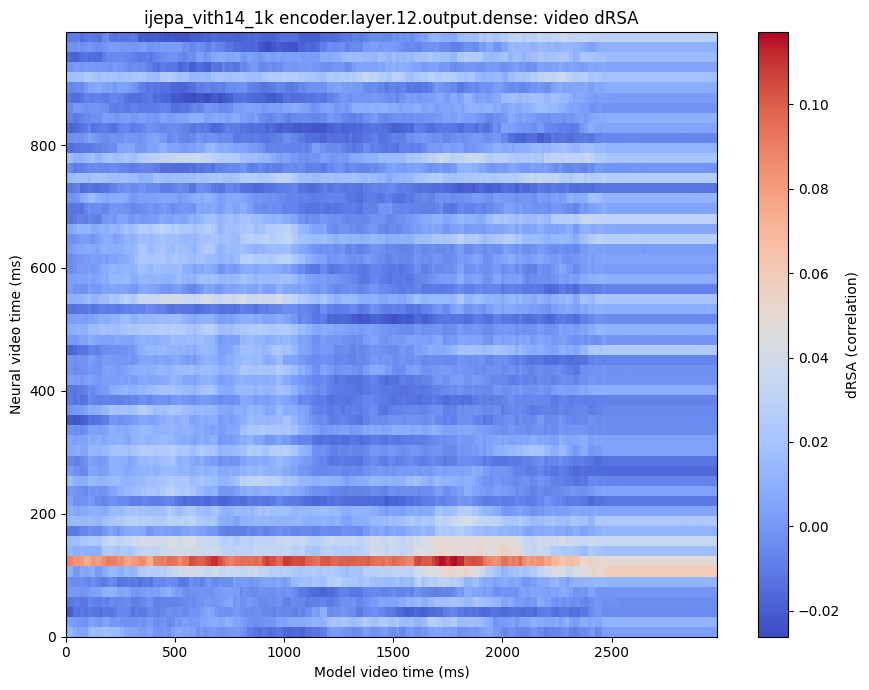

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
video_drsa_image = ax.imshow(
    example_video_drsa, aspect="auto", origin="lower", cmap="coolwarm",
    extent=[model_time_ms[0], model_time_ms[-1],
            video_time_ms[0], video_time_ms[-1]],
)
ax.set(xlabel="Model video time (ms)", ylabel="Neural video time (ms)",
       title=f"{cfg.model_name} {example_layer}: video dRSA")
fig.colorbar(video_drsa_image, ax=ax, label=f"dRSA ({cfg.video_RSA_metric})")
fig.tight_layout()

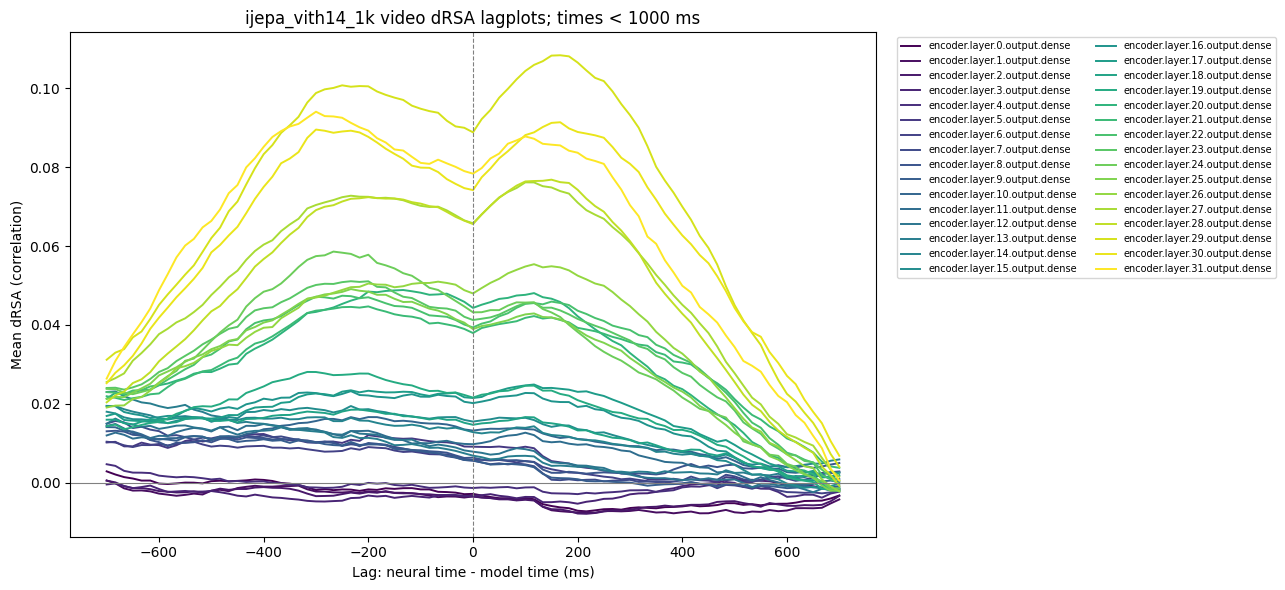

In [15]:
video_analysis_end_ms = min(
    cfg.video_lag_analysis_end_ms,
    video_neural_ts.get_duration_ms(),
    model_time_ms[-1] + 1000 / model_fs,
)
video_analysis_indices = np.flatnonzero(video_time_ms < video_analysis_end_ms)
model_analysis_indices = np.flatnonzero(model_time_ms < video_analysis_end_ms)
video_max_lag_samples = min(
    int(round(cfg.max_lag_ms * model_fs / 1000)),
    len(video_analysis_indices) - 1,
    len(model_analysis_indices) - 1,
)
video_lag_ms = (
    np.arange(-video_max_lag_samples, video_max_lag_samples + 1)
    * 1000 / model_fs
)
video_layer_lagplots = []
for layer_name in layer_names:
    video_layer_lagplots.append(get_lagplot_subset(
        video_layer_drsa[layer_name],
        neural_idx=video_analysis_indices,
        model_idx=model_analysis_indices,
        max_lag=video_max_lag_samples,
    ))
# end for layer_name
video_layer_lagplots = np.stack(video_layer_lagplots, axis=0)

layer_colors = plt.cm.viridis(np.linspace(0, 1, len(layer_names)))
fig, ax = plt.subplots(figsize=(13, 6))
for layer_index, (layer_name, layer_lagplot) in enumerate(
    zip(layer_names, video_layer_lagplots)
):
    ax.plot(video_lag_ms, layer_lagplot, color=layer_colors[layer_index],
            linewidth=1.4, label=layer_name)
# end for layer_index
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set(xlabel="Lag: neural time - model time (ms)",
       ylabel=f"Mean dRSA ({cfg.video_RSA_metric})",
       title=(f"{cfg.model_name} video dRSA lagplots; "
              f"times < {video_analysis_end_ms:g} ms"))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=2)
fig.tight_layout()